# Visual Question Answering (VQA) — CNN + LSTM Kết Hợp
## So Sánh: Train Từ Đầu vs Pretrained Model



**Hai trường hợp so sánh:**
1. **Mô hình 1 — No Attention:** GloVe 300d Embedding (frozen) + ResNet101 pretrained
   + Mean Pooling (không có cơ chế chú ý không gian)
2. **Mô hình 2 — With Attention:** GloVe 300d Embedding (frozen) + ResNet101 pretrained
   + Spatial Attention (chọn lọc 36 vùng ảnh theo câu hỏi)

**Dataset:** VQA v2.0 — dùng ảnh COCO 2014



In [1]:
# Các thư viện cơ bản
import os
import json
import pickle
import random
import zipfile
import urllib.request
from collections import Counter
from tqdm import tqdm

# Xử lý dữ liệu
import numpy as np
import pandas as pd
from PIL import Image
import nltk
from nltk.tokenize import word_tokenize

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Đánh giá
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Visualization
import matplotlib.pyplot as plt

# Thiết lập
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Fix random seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Tạo cấu trúc thư mục

In [ ]:

os.makedirs('data/vqav2/questions', exist_ok=True)
os.makedirs('data/vqav2/annotations', exist_ok=True)
os.makedirs('data/vqav2/features', exist_ok=True)
os.makedirs('data/glove', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

print("\nCấu trúc thư mục:")
!tree . -L 2


Cấu trúc thư mục:
/bin/bash: line 1: tree: command not found


## Tải GloVe 

In [3]:
def download_glove():
    """Download GloVe vectors nếu chưa có"""
    glove_path = 'data/glove/glove.6B.300d.txt'

    if not os.path.exists(glove_path):
        url = 'http://nlp.stanford.edu/data/glove.6B.zip'
        zip_path = 'data/glove/glove.6B.zip'

        # Download
        urllib.request.urlretrieve(url, zip_path)
        print("Downloaded GloVe zip")

        # Extract
        print("Extracting GloVe...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('data/glove/')

        # Clean up
        os.remove(zip_path)
        print("GloVe extracted successfully!")
    else:
        print("GloVe already exists!")

    # Kiểm tra
    files = os.listdir('data/glove')
    print(f"\nFiles in data/glove: {files}")

download_glove()

Downloaded GloVe zip
Extracting GloVe...
GloVe extracted successfully!

Files in data/glove: ['glove.6B.300d.txt', 'glove.6B.50d.txt', 'glove.6B.100d.txt', 'glove.6B.200d.txt']


## Thu thập dữ liệu 
Tiến hành tải bộ dữ liệu VQA v2 chuẩn bao gồm các câu hỏi (Questions) và đáp án (Annotations) được gán nhãn bởi con người.

In [4]:
def download_file(url, filename):
    """Download và extract file zip"""
    if os.path.exists(filename.replace('.zip', '.json')):
        print(f"{os.path.basename(filename)} already exists")
        return

    print(f"Downloading {os.path.basename(filename)}...")

    # Download
    urllib.request.urlretrieve(url, filename)

    # Extract
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(os.path.dirname(filename))

    # Clean up
    os.remove(filename)
    print(f"Downloaded and extracted {os.path.basename(filename)}")

# Download questions
print("="*50)
print("DOWNLOADING QUESTIONS")
print("="*50)

download_file(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Train_mscoco.zip',
    'data/vqav2/questions/v2_Questions_Train_mscoco.zip'
)

download_file(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip',
    'data/vqav2/questions/v2_Questions_Val_mscoco.zip'
)

# Download annotations
print("\n" + "="*50)
print("DOWNLOADING ANNOTATIONS")
print("="*50)

download_file(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Train_mscoco.zip',
    'data/vqav2/annotations/v2_Annotations_Train_mscoco.zip'
)

download_file(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip',
    'data/vqav2/annotations/v2_Annotations_Val_mscoco.zip'
)

# Kiểm tra files
print("\n" + "="*50)
print("CHECKING DOWNLOADED FILES")
print("="*50)

print("\nQuestions files:")
!ls -la data/vqav2/questions/

print("\nAnnotations files:")
!ls -la data/vqav2/annotations/

DOWNLOADING QUESTIONS
Downloaded and extracted v2_Questions_Train_mscoco.zip
Downloaded and extracted v2_Questions_Val_mscoco.zip

DOWNLOADING ANNOTATIONS
Downloaded and extracted v2_Annotations_Train_mscoco.zip
Downloaded and extracted v2_Annotations_Val_mscoco.zip

CHECKING DOWNLOADED FILES

Questions files:
total 60760
drwxr-xr-x 2 root root     4096 Mar 11 03:28 .
drwxr-xr-x 5 root root     4096 Mar 11 03:25 ..
-rw-r--r-- 1 root root 41957627 Mar 11 03:28 v2_OpenEnded_mscoco_train2014_questions.json
-rw-r--r-- 1 root root 20247670 Mar 11 03:28 v2_OpenEnded_mscoco_val2014_questions.json

Annotations files:
total 514936
drwxr-xr-x 2 root root      4096 Mar 11 03:28 .
drwxr-xr-x 5 root root      4096 Mar 11 03:25 ..
-rw-r--r-- 1 root root 355516514 Mar 11 03:28 v2_mscoco_train2014_annotations.json
-rw-r--r-- 1 root root 171762489 Mar 11 03:28 v2_mscoco_val2014_annotations.json


## Tải cơ sở dữ liệu hình ảnh (COCO Images)
Sử dụng tập dữ liệu MS COCO 2014 làm nền tảng hình ảnh cho bài toán VQA.
Tập dữ liệu: Bao gồm train2014, val2014 và test2014.

In [5]:
import os
import requests
from tqdm import tqdm
import zipfile

def download_coco_images():
    """Download ảnh COCO chính thức"""

    # Tạo thư mục
    os.makedirs('data/images', exist_ok=True)

    # URL chính thức của COCO dataset
    urls = [
        {
            'name': 'train2014',
            'url': 'http://images.cocodataset.org/zips/train2014.zip',
            'size': '13GB'
        },
        {
            'name': 'val2014',
            'url': 'http://images.cocodataset.org/zips/val2014.zip',
            'size': '6GB'
        },
        {
            'name': 'test2014',
            'url': 'http://images.cocodataset.org/zips/test2014.zip',
            'size': '6GB'
        }
    ]

    for item in urls:
        zip_path = f"data/images/{item['name']}.zip"

        # Kiểm tra nếu đã có ảnh rồi thì bỏ qua
        if os.path.exists(f"data/images/{item['name']}"):
            print(f" {item['name']} already exists")
            continue

        print(f"\n Downloading {item['name']} ({item['size']})...")
        print(f"URL: {item['url']}")

        # Download với progress bar
        response = requests.get(item['url'], stream=True)
        total_size = int(response.headers.get('content-length', 0))

        with open(zip_path, 'wb') as f:
            with tqdm(total=total_size, unit='B', unit_scale=True) as pbar:
                for chunk in response.iter_content(chunk_size=1024*1024):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))

        # Extract
        print(f" Extracting {item['name']}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('data/images/')

        # Clean up
        os.remove(zip_path)
        print(f"Done with {item['name']}")

# Chạy download
download_coco_images()


URL: http://images.cocodataset.org/zips/train2014.zip


100%|██████████| 13.5G/13.5G [04:59<00:00, 45.1MB/s]


 Extracting train2014...
Done with train2014

URL: http://images.cocodataset.org/zips/val2014.zip


100%|██████████| 6.65G/6.65G [03:07<00:00, 35.5MB/s]


 Extracting val2014...
Done with val2014

URL: http://images.cocodataset.org/zips/test2014.zip


100%|██████████| 6.66G/6.66G [02:30<00:00, 44.4MB/s]


 Extracting test2014...
Done with test2014


## Định nghĩa Vocabulary Class

In [ ]:
class VQAVocabulary:
    """Xây dựng vocabulary từ VQA v2.0 dataset"""

    def __init__(self, freq_threshold=2, answer_threshold=5, max_vocab_size=10000):
        self.freq_threshold = freq_threshold
        self.answer_threshold = answer_threshold
        self.max_vocab_size = max_vocab_size

        # Special tokens
        self.special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
        self.pad_idx = 0
        self.start_idx = 1
        self.end_idx = 2
        self.unk_idx = 3

        # Dictionaries
        self.question_word2idx = {}
        self.question_idx2word = {}
        self.answer_word2idx = {}
        self.answer_idx2word = {}
        self.answer_list = []

    def load_json(self, path):
        """Load JSON file"""
        with open(path, 'r') as f:
            return json.load(f)

    def build_from_files(self, q_train_path, a_train_path):
        """Build vocabulary từ train files"""
        print("="*60)
        print("BUILDING VOCABULARY")
        print("="*60)

        print("\n Loading questions...")
        q_data = self.load_json(q_train_path)
        questions = [item['question'] for item in q_data['questions']]
        print(f"   Loaded {len(questions):,} questions")

        print("\n Loading answers...")
        a_data = self.load_json(a_train_path)
        all_answers = []
        for ann in tqdm(a_data['annotations'], desc="Processing answers"):
            answers = [ans['answer'] for ans in ann['answers']]
            all_answers.extend(answers)
        print(f"   Loaded {len(all_answers):,} answers")

        print("\n Building question vocabulary...")
        self._build_question_vocab(questions)

        print("\n Building answer vocabulary...")
        self._build_answer_vocab(all_answers)

        
        self._print_statistics(questions, all_answers)

        return self

    def _build_question_vocab(self, questions):
        """Build vocabulary cho câu hỏi"""
        # Đếm tần suất xuất hiện của từ
        word_counts = Counter()
        for q in tqdm(questions, desc="Counting words"):
            tokens = word_tokenize(q.lower())
            word_counts.update(tokens)

        # Thêm special tokens
        for token in self.special_tokens:
            self.question_word2idx[token] = len(self.question_word2idx)

        # Thêm các từ đáp ứng ngưỡng tần suất
        for word, count in word_counts.most_common():
            if count >= self.freq_threshold and word not in self.question_word2idx:
                self.question_word2idx[word] = len(self.question_word2idx)
                if len(self.question_word2idx) >= self.max_vocab_size:
                    break

        # Build idx2word
        self.question_idx2word = {idx: word for word, idx in self.question_word2idx.items()}

        print(f"   Question vocab size: {len(self.question_word2idx):,}")

    def _build_answer_vocab(self, answers):
        """Build vocabulary cho câu trả lời theo TỪNG TỪ (cho LSTM Decoder)"""
        word_counts = Counter()
        for ans in tqdm(answers, desc="Counting answer words"):
            tokens = word_tokenize(ans.lower()) 
            word_counts.update(tokens)

        # Add special tokens
        for token in self.special_tokens:
            self.answer_word2idx[token] = len(self.answer_word2idx)

        # Add words meeting threshold
        for word, count in word_counts.most_common():
            if count >= self.answer_threshold and word not in self.answer_word2idx:
                self.answer_word2idx[word] = len(self.answer_word2idx)
                if len(self.answer_word2idx) >= self.max_vocab_size:
                    break

        self.answer_idx2word = {idx: word for word, idx in self.answer_word2idx.items()}
        self.answer_list = list(self.answer_word2idx.keys())
        print(f"   Answer vocab size: {len(self.answer_word2idx):,}")

    def _print_statistics(self, questions, answers):
        """In thống kê"""
        # Question coverage
        q_coverage = self._compute_coverage(questions, 'question')

        # Answer coverage
        a_coverage = sum(1 for ans in answers if ans in self.answer_word2idx) / len(answers)

        print("\n" + "="*60)
        print("VOCABULARY STATISTICS")
        print("="*60)
        print(f"Question vocabulary: {len(self.question_word2idx):,} words")
        print(f"  - Coverage: {q_coverage:.2%}")
        print(f"Answer vocabulary: {len(self.answer_word2idx):,} words")
        print(f"  - Coverage: {a_coverage:.2%}")
        print(f"  - Top answers: {self.answer_list[:10]}")

    def _compute_coverage(self, sentences, mode='question'):
        """Tính coverage của vocabulary"""
        total_tokens = 0
        covered_tokens = 0
        vocab = self.question_word2idx if mode == 'question' else self.answer_word2idx

        for sent in sentences[:10000]:  
            tokens = word_tokenize(sent.lower())
            total_tokens += len(tokens)
            covered_tokens += sum(1 for t in tokens if t in vocab)

        return covered_tokens / total_tokens if total_tokens > 0 else 0

    def encode_question(self, question, max_len=14):
        """Encode câu hỏi thành indices"""
        tokens = word_tokenize(question.lower())
        indices = []

        for token in tokens:
            if token in self.question_word2idx:
                indices.append(self.question_word2idx[token])
            else:
                indices.append(self.question_word2idx['<unk>'])

        # Thêm phần đệm hoặc cắt bớt
        if len(indices) < max_len:
            indices += [self.question_word2idx['<pad>']] * (max_len - len(indices))
        else:
            indices = indices[:max_len]

        return indices

    def encode_answer(self, answer, max_len=10):
        """Encode câu trả lời thành indices (cho decoder)"""
        tokens = ['<start>'] + word_tokenize(answer.lower()) + ['<end>']
        indices = []

        for token in tokens:
            if token in self.answer_word2idx:
                indices.append(self.answer_word2idx[token])
            else:
                indices.append(self.answer_word2idx['<unk>'])

        # Thêm phần đệm hoặc cắt bớt
        if len(indices) < max_len:
            indices += [self.answer_word2idx['<pad>']] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
            indices[-1] = self.answer_word2idx['<end>']

        return indices

    def decode_answer(self, indices):
        """Decode indices thành câu trả lời"""
        tokens = []
        for idx in indices:
            if idx == self.end_idx:
                break
            if idx not in [self.pad_idx, self.start_idx]:
                tokens.append(self.answer_idx2word.get(idx, '<unk>'))
        return ' '.join(tokens)

    def save(self, path='data/vocab.pkl'):
        """Lưu vocabulary"""
        with open(path, 'wb') as f:
            pickle.dump({
                'question_word2idx': self.question_word2idx,
                'question_idx2word': self.question_idx2word,
                'answer_word2idx': self.answer_word2idx,
                'answer_idx2word': self.answer_idx2word,
                'answer_list': self.answer_list,
                'special_tokens': self.special_tokens
            }, f)
        print(f" Vocabulary saved to {path}")

    def load(self, path='data/vocab.pkl'):
        """Load vocabulary"""
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.question_word2idx = data['question_word2idx']
            self.question_idx2word = data['question_idx2word']
            self.answer_word2idx = data['answer_word2idx']
            self.answer_idx2word = data['answer_idx2word']
            self.answer_list = data['answer_list']
            self.special_tokens = data['special_tokens']
        print(f" Vocabulary loaded from {path}")
        return self

## Tải các gói NLTK cần thiết

In [ ]:

import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

print("Đang tải gói 'punkt' và 'punkt_tab' cho NLTK...")
nltk.download('punkt')
nltk.download('punkt_tab')
print("Tải xong!")

from nltk.tokenize import word_tokenize
test_sentence = "This is a test sentence."
tokens = word_tokenize(test_sentence)
print(f"Tokenize thử: {tokens}")

Đang tải gói 'punkt' và 'punkt_tab' cho NLTK...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tải xong!
Tokenize thử: ['This', 'is', 'a', 'test', 'sentence', '.']


## Xây dựng Vocabulary

In [ ]:

q_train_path = 'data/vqav2/questions/v2_OpenEnded_mscoco_train2014_questions.json'
a_train_path = 'data/vqav2/annotations/v2_mscoco_train2014_annotations.json'

# Kiểm tra file tồn tại
if not os.path.exists(q_train_path):
    print(f" File not found: {q_train_path}")
else:
    # Build vocabulary
    vocab = VQAVocabulary(freq_threshold=2, answer_threshold=5)
    vocab.build_from_files(q_train_path, a_train_path)

    # Save vocabulary
    vocab.save('data/vocab.pkl')

    # Test encoding/decoding
    print("\n" + "="*60)
    print("TEST ENCODING/DECODING")
    print("="*60)

    test_question = "What color is the cat?"
    test_answer = "black cat"

    q_encoded = vocab.encode_question(test_question)
    a_encoded = vocab.encode_answer(test_answer)
    a_decoded = vocab.decode_answer(a_encoded)

    print(f"Question: {test_question}")
    print(f"Encoded: {q_encoded}")
    print(f"Answer: {test_answer}")
    print(f"Encoded: {a_encoded}")
    print(f"Decoded: {a_decoded}")

BUILDING VOCABULARY

 Loading questions...
   Loaded 443,757 questions

 Loading answers...


Processing answers: 100%|██████████| 443757/443757 [00:00<00:00, 1054221.19it/s]


   Loaded 4,437,570 answers

 Building question vocabulary...


Counting words: 100%|██████████| 443757/443757 [00:17<00:00, 24740.57it/s]


   Question vocab size: 10,000

 Building answer vocabulary...


Counting answer words: 100%|██████████| 4437570/4437570 [01:34<00:00, 46877.59it/s]


   Answer vocab size: 10,000

VOCABULARY STATISTICS
Question vocabulary: 10,000 words
  - Coverage: 99.95%
Answer vocabulary: 10,000 words
  - Coverage: 88.25%
  - Top answers: ['<pad>', '<start>', '<end>', '<unk>', 'no', 'yes', '2', '1', 'white', 'black']
 Vocabulary saved to data/vocab.pkl

TEST ENCODING/DECODING
Question: What color is the cat?
Encoded: [7, 16, 6, 5, 47, 4, 0, 0, 0, 0, 0, 0, 0, 0]
Answer: black cat
Encoded: [1, 9, 45, 2, 0, 0, 0, 0, 0, 0]
Decoded: black cat


## Load GloVe Embeddings

In [ ]:

def load_glove_embeddings(glove_path, vocab, embedding_dim=300):
    """Load GloVe vectors và tạo embedding matrix"""

    print(" Loading GloVe embeddings...")

    # Khởi tạo ma trận nhúng với các giá trị ngẫu nhiên.
    embedding_matrix = np.random.normal(scale=0.6, size=(len(vocab.question_word2idx), embedding_dim))

    # Load GloVe
    glove_dict = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Loading GloVe"):
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_dict[word] = vector

    # Điền ma trận nhúng
    found = 0
    for word, idx in vocab.question_word2idx.items():
        if word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
            found += 1
        elif word.lower() in glove_dict:
            embedding_matrix[idx] = glove_dict[word.lower()]
            found += 1

    print(f" Found GloVe vectors for {found}/{len(vocab.question_word2idx)} words ({found/len(vocab.question_word2idx):.2%})")

    return torch.from_numpy(embedding_matrix).float()

# Load GloVe
glove_path = 'data/glove/glove.6B.300d.txt'
pretrained_embeddings = load_glove_embeddings(glove_path, vocab, 300)

print(f"\nEmbedding matrix shape: {pretrained_embeddings.shape}")

 Loading GloVe embeddings...


Loading GloVe: 400000it [00:28, 14258.48it/s]


 Found GloVe vectors for 9811/10000 words (98.11%)

Embedding matrix shape: torch.Size([10000, 300])


## Bộ trích xuất đặc điểm hình ảnh

In [ ]:
 
class ImageFeatureExtractor:
    """Extract features từ ảnh gốc sử dụng ResNet"""

    def __init__(self, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.device = device
        print(f"Using device: {self.device}")

        # Load pretrained ResNet101
        print("Loading ResNet101 pretrained on ImageNet...")
        resnet = models.resnet101(pretrained=True)

        # Bỏ lớp FC cuối, giữ feature map
        self.feature_extractor = torch.nn.Sequential(
            *list(resnet.children())[:-2]
        ).to(device)

        # Set to evaluation mode
        self.feature_extractor.eval()

        # Transform cho ảnh đầu vào
        self.transform = transforms.Compose([
            transforms.Resize((448, 448)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        print(" Feature extractor ready!")

    def extract_single_image(self, image_path):
        """Extract features cho 1 ảnh"""
        try:
            # Load và transform ảnh
            image = Image.open(image_path).convert('RGB')
            image_tensor = self.transform(image).unsqueeze(0).to(self.device)

            # Extract features
            with torch.no_grad():
                features = self.feature_extractor(image_tensor)  # [1, 2048, 14, 14]

                # Nhóm thích ứng để lấy 36 vùng
                features = features.squeeze(0)  # [2048, 14, 14]
                features = features.permute(1, 2, 0)  # [14, 14, 2048]

                # Gộp dữ liệu đơn giản: lấy lưới 6x6
                pooled = []
                for i in range(0, 14, 2):
                    for j in range(0, 14, 2):
                        region = features[i:i+2, j:j+2].mean(dim=(0,1))
                        pooled.append(region)

                features = torch.stack(pooled[:36])  # [36, 2048]

            return features.cpu().numpy()

        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return np.zeros((36, 2048), dtype=np.float32)

# Khởi tạo extractor
extractor = ImageFeatureExtractor()

Using device: cuda
Loading ResNet101 pretrained on ImageNet...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 163MB/s]


 Feature extractor ready!


## Dataset Class : Dataset cho VQA sử dụng ảnh gốc

In [ ]:

class VQADatasetWithImages(Dataset):

    def __init__(self,
                 question_file,
                 annotation_file,
                 image_dir,
                 vocab,
                 extractor,
                 max_q_len=14,
                 max_a_len=10,
                 split='train',
                 max_samples=None):

        self.vocab = vocab
        self.max_q_len = max_q_len
        self.max_a_len = max_a_len
        self.split = split
        self.image_dir = image_dir
        self.extractor = extractor

        # Load questions
        print(f"Loading {split} questions...")
        with open(question_file, 'r') as f:
            self.questions = json.load(f)['questions']

        # Giới hạn số samples nếu cần
        if max_samples:
            self.questions = self.questions[:max_samples]

        # Load annotations
        if annotation_file and os.path.exists(annotation_file):
            print(f"Loading {split} annotations...")
            with open(annotation_file, 'r') as f:
                self.annotations = json.load(f)['annotations']
            self.ann_dict = {ann['question_id']: ann for ann in self.annotations}
        else:
            self.annotations = None
            self.ann_dict = {}

        print(f"Loaded {len(self.questions)} samples")

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        # Get question
        q_item = self.questions[idx]
        q_id = q_item['question_id']
        img_id = q_item['image_id']
        q_text = q_item['question']

        # Get answer
        if q_id in self.ann_dict:
            ann = self.ann_dict[q_id]
            answers = [a['answer'] for a in ann['answers']]
            answer_counts = Counter(answers)
            gt_answer = answer_counts.most_common(1)[0][0]
        else:
            gt_answer = "<unk>"

        # Load image và extract features
        img_filename = f"COCO_{self.split}2014_{img_id:012d}.jpg"
        img_path = os.path.join(self.image_dir, img_filename)

        if os.path.exists(img_path):
            image_features = self.extractor.extract_single_image(img_path)
        else:
            # Thử với train2014 nếu là validation
            if self.split == 'val':
                alt_path = os.path.join('data/images/train2014', img_filename)
                if os.path.exists(alt_path):
                    image_features = self.extractor.extract_single_image(alt_path)
                else:
                    image_features = np.zeros((36, 2048), dtype=np.float32)
            else:
                image_features = np.zeros((36, 2048), dtype=np.float32)

        # Encode
        q_encoded = self.vocab.encode_question(q_text, self.max_q_len)
        a_encoded = self.vocab.encode_answer(gt_answer, self.max_a_len)

        return {
            'image_features': torch.FloatTensor(image_features),
            'question': torch.LongTensor(q_encoded),
            'answer': torch.LongTensor(a_encoded),
            'question_id': q_id,
            'image_id': img_id,
            'question_text': q_text,
            'answer_text': gt_answer
        }

## Tạo DataLoader

In [ ]:

from torch.utils.data import DataLoader

# Đường dẫn
image_dir = 'data/images/train2014'  # Thư mục chứa ảnh train
q_train = 'data/vqav2/questions/v2_OpenEnded_mscoco_train2014_questions.json'
q_val = 'data/vqav2/questions/v2_OpenEnded_mscoco_val2014_questions.json'
a_train = 'data/vqav2/annotations/v2_mscoco_train2014_annotations.json'
a_val = 'data/vqav2/annotations/v2_mscoco_val2014_annotations.json'



train_dataset = VQADatasetWithImages(
    question_file=q_train,
    annotation_file=a_train,
    image_dir=image_dir,
    vocab=vocab,
    extractor=extractor,
    max_q_len=14,
    max_a_len=10,
    split='train',
    max_samples= 10000
)

val_dataset = VQADatasetWithImages(
    question_file=q_val,
    annotation_file=a_val,
    image_dir='data/images/val2014',
    vocab=vocab,
    extractor=extractor,
    max_q_len=14,
    max_a_len=10,
    split='val',
    max_samples=2000
)

# DataLoader
batch_size = 16  # Giảm batch_size vì extract features on-the-fly

num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(num_workers > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(num_workers > 0)
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Loading train questions...
Loading train annotations...
Loaded 10000 samples
Loading val questions...
Loading val annotations...
Loaded 2000 samples

Train batches: 625
Val batches: 125


In [ ]:

sample = train_dataset[0]

print("SAMPLE DATA:")
print("="*50)
print(f"Image features shape: {sample['image_features'].shape}")
print(f"Question indices shape: {sample['question'].shape}")
print(f"Answer indices shape: {sample['answer'].shape}")
print(f"Question text: {sample['question_text']}")
print(f"Answer text: {sample['answer_text']}")

SAMPLE DATA:
Image features shape: torch.Size([36, 2048])
Question indices shape: torch.Size([14])
Answer indices shape: torch.Size([10])
Question text: What is this photo taken looking through?
Answer text: net


## Model No Attention

In [14]:
class VQAModelNoAttention(nn.Module):
    def __init__(self,
                 vocab_size,
                 answer_size,
                 feature_dim=2048,
                 embed_size=300,
                 hidden_size=512,
                 num_layers=2,
                 dropout=0.3,
                 pretrained_embeddings=None):

        super(VQAModelNoAttention, self).__init__()

        self.vocab_size = vocab_size
        self.answer_size = answer_size
        self.hidden_size = hidden_size
        self.start_idx = 1
        self.end_idx = 2
        # Image Encoder
        self.image_fc = nn.Sequential(
            nn.Linear(feature_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Question Encoder (Bidirectional)
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = False

        self.question_lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.question_proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Gated Fusion
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Sigmoid()
        )
        self.fusion_norm = nn.LayerNorm(hidden_size)

        # Decoder
        self.decoder_embedding = nn.Embedding(answer_size, embed_size, padding_idx=0)
        self.decoder_lstm = nn.LSTMCell(embed_size + hidden_size, hidden_size)
        self.decoder_fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, answer_size)
        )
        self.dropout = nn.Dropout(dropout)



    def encode_image(self, image_features):
        img_feat = image_features.mean(dim=1)
        return self.image_fc(img_feat)

    def encode_question(self, questions):
        q_embed = self.embedding(questions)
        lstm_out, (hidden, _) = self.question_lstm(q_embed)
        h_forward = hidden[-2]
        h_backward = hidden[-1]
        q_combined = torch.cat([h_forward, h_backward], dim=1)
        return self.question_proj(q_combined)

    def gated_fusion(self, v_img, q_ques):
        combined = torch.cat([v_img, q_ques], dim=1)
        gate = self.fusion_gate(combined)
        fused = gate * v_img + (1 - gate) * q_ques
        return self.fusion_norm(fused)

    def forward(self, image_features, questions, answers=None, max_len=10):
        # Encode
        v_img = self.encode_image(image_features)
        v_ques = self.encode_question(questions)

        # Fusion
        joint = self.gated_fusion(v_img, v_ques)

        # Decoder
        batch_size = joint.size(0)
        h = joint
        c = torch.tanh(joint)

        if answers is not None:  # Training mode - teacher forcing
            seq_len = answers.size(1) - 1
            outputs = []
            input_token = torch.full(
                  (batch_size,),
                  self.start_idx,
                  dtype=torch.long,
                  device=joint.device
              )

            for t in range(seq_len):
                token_embed = self.dropout(self.decoder_embedding(input_token))
                lstm_input = torch.cat([token_embed, joint], dim=1)
                h, c = self.decoder_lstm(lstm_input, (h, c))
                logits = self.decoder_fc(self.dropout(h))
                outputs.append(logits)
                input_token = answers[:, t + 1]

            return torch.stack(outputs, dim=1)  # [batch, seq_len, answer_size]

        else:  # Inference mode - greedy decoding
            predictions = []
            input_token = torch.full(
                (batch_size,),
                self.start_idx,
                dtype=torch.long,
                device=joint.device
            )

            for _ in range(max_len):
                token_embed = self.dropout(self.decoder_embedding(input_token))
                lstm_input = torch.cat([token_embed, joint], dim=1)
                h, c = self.decoder_lstm(lstm_input, (h, c))
                logits = self.decoder_fc(self.dropout(h))
                predicted = logits.argmax(1)
                predictions.append(predicted)
                input_token = predicted.detach()

                if (predicted == self.end_idx).all():
                    break

            # Stack predictions: [seq_len, batch] -> [batch, seq_len]
            return torch.stack(predictions, dim=1)


## Trainer No Attention

In [ ]:

class TrainerNoAttention:
    def __init__(self, model, train_loader, val_loader, vocab, device, class_weights=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.vocab = vocab
        self.device = device


        self.criterion = nn.CrossEntropyLoss(
            ignore_index=0,
            label_smoothing=0.1
        )

        # Optimizer
        self.optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=5, T_mult=2, eta_min=1e-6
        )
        self.grad_clip = 1.0

        # History
        self.train_losses = []
        self.val_losses = []
        self.val_accuracies = []
        self.best_val_acc = 0.0

    def train_epoch(self):
        self.model.train()
        total_loss = 0

        pbar = tqdm(self.train_loader, desc='Training')
        for batch in pbar:
            img_feat = batch['image_features'].to(self.device)
            ques = batch['question'].to(self.device)
            ans = batch['answer'].to(self.device)

            outputs = self.model(img_feat, ques, ans)

            outputs_flat = outputs.reshape(-1, outputs.size(-1))
            targets_flat = ans[:, 1:].reshape(-1)
            loss = self.criterion(outputs_flat, targets_flat)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        return total_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        predictions_list = []
        targets_list = []

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='Validating'):
                img_feat = batch['image_features'].to(self.device)
                ques = batch['question'].to(self.device)
                ans = batch['answer'].to(self.device)

                outputs_tf = self.model(img_feat, ques, ans)
                outputs_flat = outputs_tf.reshape(-1, outputs_tf.size(-1))
                targets_flat = ans[:, 1:].reshape(-1)
                loss = self.criterion(outputs_flat, targets_flat)
                total_loss += loss.item()

                predictions = self.model(img_feat, ques)

                targets = ans[:, 1:]
                pred_len = predictions.size(1)
                tgt_len  = targets.size(1)
                if pred_len < tgt_len:
                    pad = torch.zeros(predictions.size(0), tgt_len - pred_len,
                                      dtype=torch.long).to(self.device)
                    predictions = torch.cat([predictions, pad], dim=1)
                elif pred_len > tgt_len:
                    predictions = predictions[:, :tgt_len]

                mask = targets != 0
                correct += ((predictions == targets) * mask).sum().item()
                total   += mask.sum().item()

                if len(predictions_list) < 20:
                    for i in range(min(2, len(predictions))):
                        pred_text   = self.vocab.decode_answer(predictions[i].cpu().numpy())
                        target_text = batch['answer_text'][i]
                        predictions_list.append(pred_text)
                        targets_list.append(target_text)

        accuracy = correct / total if total > 0 else 0

        print(f"\n Mẫu dự đoán (validation):")
        for i in range(min(5, len(predictions_list))):
            print(f"   Target: {targets_list[i][:30]:<30} | Predict: {predictions_list[i][:30]}")

        return total_loss / len(self.val_loader), accuracy

    def train(self, epochs=15):
        print(" BẮT ĐẦU TRAINING NO ATTENTION ")
        print("="*60)
        patience = 4
        patience_counter = 0
        for epoch in range(epochs):
            print(f"\n Epoch {epoch+1}/{epochs}")
            print("-"*40)

            train_loss = self.train_epoch()
            val_loss, val_acc = self.validate()
            self.scheduler.step(epoch + 1)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)

            print(f"\n KẾT QUẢ EPOCH {epoch+1}:")
            print(f"   Train Loss: {train_loss:.4f}")
            print(f"   Val Loss: {val_loss:.4f}")
            print(f"   Val Accuracy: {val_acc:.4f}")

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                torch.save(self.model.state_dict(), 'checkpoints/best_no_attn_model.pth')
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered")
                break

        print("\n" + "="*60)
        print("TRAINING COMPLETED!")
        self.plot_results()

    def plot_results(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(self.train_losses, 'b-', label='Train Loss')
        axes[0].plot(self.val_losses, 'r-', label='Val Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(self.val_accuracies, 'g-', label='Val Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        print(f"\n Best Accuracy: {max(self.val_accuracies):.2%}")
        print(f"   Final Accuracy: {self.val_accuracies[-1]:.2%}")

 Model No Attention đã khởi tạo!
 Số parameters: 26,107,536
 BẮT ĐẦU TRAINING NO ATTENTION 

 Epoch 1/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:04<00:00,  1.95it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: <unk>
   Target: watching                       | Predict: <unk>
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 1:
   Train Loss: 3.7906
   Val Loss: 3.1426
   Val Accuracy: 0.5610

 Epoch 2/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.97it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: on
   Target: watching                       | Predict: tennis
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 2:
   Train Loss: 3.1622
   Val Loss: 3.0684
   Val Accuracy: 0.5720

 Epoch 3/15
----------------------------------------


...


 Mẫu dự đoán (validation):
   Target: down                           | Predict: left
   Target: watching                       | Predict: skateboarding
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 9:
   Train Loss: 2.7342
   Val Loss: 2.9682
   Val Accuracy: 0.5775

 Epoch 10/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.96it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: park
   Target: watching                       | Predict: skateboarding
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: no

 KẾT QUẢ EPOCH 10:
   Train Loss: 2.6670
   Val Loss: 2.9578
   Val Accuracy: 0.5806

 Epoch 11/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.97it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: park
   Target: watching                       | Predict: skateboarding
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 11:
   Train Loss: 2.6157
   Val Loss: 2.9371
   Val Accuracy: 0.5832
Early stopping triggered

TRAINING COMPLETED!


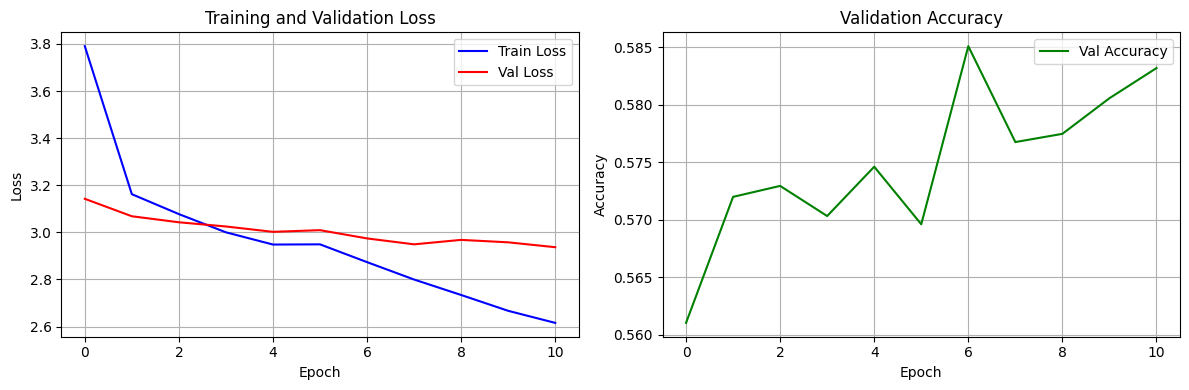


 Best Accuracy: 58.51%
   Final Accuracy: 58.32%


In [ ]:

model_noattn = VQAModelNoAttention(
    vocab_size=len(vocab.question_word2idx),
    answer_size=len(vocab.answer_word2idx),
    feature_dim=2048,
    embed_size=300,
    hidden_size=512,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(" Model No Attention đã khởi tạo!")
print(f" Số parameters: {sum(p.numel() for p in model_noattn.parameters()):,}")

# Khởi tạo trainer
trainer_noattn = TrainerNoAttention(
    model_noattn, train_loader, val_loader, vocab, device

)

# Train
trainer_noattn.train(epochs=15)

In [17]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=2d22c69fc024ee76fa47211304f6147511c7997376dedf52384bde5d6d1c9054
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


##  Đánh giá chi tiết với nhiều metrics

In [ ]:

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

class FullEvaluator:
    def __init__(self, model, vocab, device):
        self.model = model
        self.vocab = vocab
        self.device = device
        self.smooth = SmoothingFunction().method4
        self.rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    def evaluate(self, test_loader, num_samples=20):
        self.model.eval()

        token_acc = 0
        token_total = 0
        exact_matches = []
        bleu_scores = []
        meteor_scores = []
        rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
        samples = []

        with torch.no_grad():
            for batch in tqdm(test_loader, desc='Evaluating'):
                img_feat = batch['image_features'].to(self.device)
                ques     = batch['question'].to(self.device)
                ans      = batch['answer'].to(self.device)

                predictions = self.model(img_feat, ques)

                targets = ans[:, 1:]
                pred_len = predictions.size(1)
                tgt_len  = targets.size(1)
                if pred_len < tgt_len:
                    pad = torch.zeros(predictions.size(0), tgt_len - pred_len,
                                      dtype=torch.long).to(self.device)
                    predictions_padded = torch.cat([predictions, pad], dim=1)
                else:
                    predictions_padded = predictions[:, :tgt_len]

                mask = targets != 0
                token_acc   += ((predictions_padded == targets) * mask).sum().item()
                token_total += mask.sum().item()

                for i in range(len(predictions)):
                    pred_text   = self.vocab.decode_answer(predictions[i].cpu().numpy())
                    target_text = self.vocab.decode_answer(targets[i].cpu().numpy())

                    exact_matches.append(1 if pred_text == target_text else 0)

                    if pred_text.strip() and target_text.strip():
                        bleu = sentence_bleu([target_text.split()], pred_text.split(),
                                            weights=(0.25, 0.25, 0.25, 0.25),
                                            smoothing_function=self.smooth)
                        bleu_scores.append(bleu)
                        meteor = meteor_score([target_text.split()], pred_text.split())
                        meteor_scores.append(meteor)

                        rs = self.rouge.score(target_text, pred_text)
                        rouge_scores['rouge1'].append(rs['rouge1'].fmeasure)
                        rouge_scores['rouge2'].append(rs['rouge2'].fmeasure)
                        rouge_scores['rougeL'].append(rs['rougeL'].fmeasure)

                    if len(samples) < num_samples:
                        samples.append({
                            'question':    batch['question_text'][i],
                            'target':      target_text,
                            'prediction':  pred_text
                        })

        results = {
            'token_accuracy': token_acc / token_total if token_total > 0 else 0,
            'exact_match':    sum(exact_matches) / len(exact_matches) if exact_matches else 0,
            'bleu':           sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0,
            'rouge1':         sum(rouge_scores['rouge1']) / len(rouge_scores['rouge1']) if rouge_scores['rouge1'] else 0,
            'rouge2':         sum(rouge_scores['rouge2']) / len(rouge_scores['rouge2']) if rouge_scores['rouge2'] else 0,
            'rougeL':         sum(rouge_scores['rougeL']) / len(rouge_scores['rougeL']) if rouge_scores['rougeL'] else 0,
            'meteor':         sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0,
            'samples':        samples
        }
        return results

    def print_results(self, results):
        print("\n" + "="*60)
        print(" ĐÁNH GIÁ TOÀN DIỆN")
        print("="*60)
        print(f"Token-level Accuracy: {results['token_accuracy']:.2%}")
        print(f"Sentence-level Exact Match: {results['exact_match']:.2%}")
        print(f"BLEU-4 Score: {results['bleu']:.4f}")
        print(f"ROUGE-1: {results['rouge1']:.4f}")
        print(f"ROUGE-2: {results['rouge2']:.4f}")
        print(f"ROUGE-L: {results['rougeL']:.4f}")

        print("\n" + "="*60)
        print(" MẪU DỰ ĐOÁN")
        print("="*60)
        for i, sample in enumerate(results['samples'][:10]):
            print(f"\n{i+1}. Q: {sample['question']}")
            print(f"   Target: {sample['target']}")
            print(f"   Predict: {sample['prediction']}")
            if sample['prediction'] == sample['target']:
                print(f"    ĐÚNG")
            else:
                bleu = sentence_bleu([sample['target'].split()], sample['prediction'].split() if sample['prediction'] else [],
                                    weights=(0.25, 0.25, 0.25, 0.25),
                                    smoothing_function=SmoothingFunction().method4)
                print(f"    BLEU-4: {bleu:.4f}")


In [ ]:
evaluator_full = FullEvaluator(model_noattn, vocab, device)
results = evaluator_full.evaluate(val_loader, num_samples=20)
evaluator_full.print_results(results)

Evaluating: 100%|██████████| 125/125 [01:14<00:00,  1.67it/s]


 ĐÁNH GIÁ TOÀN DIỆN
Token-level Accuracy: 58.32%
Sentence-level Exact Match: 29.00%
BLEU-4 Score: 0.2925
ROUGE-1: 0.3014
ROUGE-2: 0.0015
ROUGE-L: 0.3014

 MẪU DỰ ĐOÁN

1. Q: Where is he looking?
   Target: down
   Predict: park
    BLEU-4: 0.0000

2. Q: What are the people in the background doing?
   Target: watching
   Predict: skateboarding
    BLEU-4: 0.0000

3. Q: What is he on top of?
   Target: picnic table
   Predict: skateboard
    BLEU-4: 0.0000

4. Q: What website copyrighted the picture?
   Target: <unk>
   Predict: pepperoni
    BLEU-4: 0.0000

5. Q: Is this a creamy soup?
   Target: no
   Predict: yes
    BLEU-4: 0.0000

6. Q: Is this rice noodle soup?
   Target: yes
   Predict: yes
    ĐÚNG

7. Q: What is to the right of the soup?
   Target: chopsticks
   Predict: broccoli
    BLEU-4: 0.0000

8. Q: What is the man doing in the street?
   Target: walking
   Predict: street
    BLEU-4: 0.0000

9. Q: How many photo's can you see?
   Target: 1
   Predict: 1
    ĐÚNG

10. Q: 

## Cơ chế Spatial Attention (Chú ý không gian)

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpatialAttention(nn.Module):
    def __init__(self, v_dim=2048, q_dim=512, hidden_dim=512, dropout=0.3):
        super(SpatialAttention, self).__init__()

        # Biến đổi đặc trưng ảnh và câu hỏi về cùng một không gian (hidden_dim)
        self.v_proj = nn.Linear(v_dim, hidden_dim)
        self.q_proj = nn.Linear(q_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

        # Lớp tính điểm Attention (Attention score)
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, v_features, q_feature):
        """
        v_features: [batch_size, 36, 2048] (36 vùng ảnh)
        q_feature:  [batch_size, 512] (Đặc trưng câu hỏi)
        """
        # Copy câu hỏi ra 36 bản để so khớp với 36 vùng ảnh
        q_expanded = q_feature.unsqueeze(1)  # [batch_size, 1, hidden_dim]

        # Biến đổi tuyến tính
        v_proj = self.v_proj(self.dropout(v_features)) # [batch_size, 36, hidden_dim]
        q_proj = self.q_proj(self.dropout(q_expanded)) # [batch_size, 1, hidden_dim]

        # Tính năng lượng (tanh) kết hợp giữa Ảnh và Câu hỏi
        h = torch.tanh(v_proj + q_proj)  # [batch_size, 36, hidden_dim]

        # Tính trọng số Attention (softmax) để tổng các trọng số = 1
        attn_scores = self.attn(h)  # [batch_size, 36, 1]
        attn_weights = F.softmax(attn_scores, dim=1)  # [batch_size, 36, 1]

        # Nhân chập trọng số với đặc trưng ảnh ban đầu để ra vector ngữ cảnh (Context Vector)
        attended_image = torch.sum(attn_weights * v_features, dim=1)  # [batch_size, 2048]

        return attended_image, attn_weights

## Model With Attention

In [ ]:
class VQAModelWithAttention(nn.Module):
    def __init__(self, vocab_size, answer_size, feature_dim=2048, embed_size=300, hidden_size=512, num_layers=2, dropout=0.3, pretrained_embeddings=None):
        super(VQAModelWithAttention, self).__init__()

        self.hidden_size = hidden_size
        self.answer_size = answer_size
        self.start_idx = 1
        self.end_idx = 2
        # 1. Question Encoder (Bi-LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = False
        self.question_lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True
        )
        self.question_proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # 2. Attention Module
        self.attention = SpatialAttention(v_dim=feature_dim, q_dim=hidden_size, hidden_dim=hidden_size, dropout=dropout)

        # 3. Image Encoder (Sau khi đã được tính Attention)
        self.image_fc = nn.Sequential(
            nn.Linear(feature_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # 4. Trộn Ảnh và Chữ
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Sigmoid()
        )
        self.fusion_norm = nn.LayerNorm(hidden_size)

        # 5. Decoder (LSTMCell sinh từ tuần tự)
        self.decoder_embedding = nn.Embedding(answer_size, embed_size, padding_idx=0)
        self.decoder_lstm = nn.LSTMCell(embed_size + hidden_size, hidden_size)
        self.decoder_fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, answer_size)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, image_features, questions, answers=None, max_len=10):
        # image_features: [batch_size, 36, 2048]
        batch_size = image_features.size(0)

        # A. Encode Câu hỏi
        q_embed = self.embedding(questions)
        _, (hidden, _) = self.question_lstm(q_embed)
        # Nối hidden state của 2 chiều lại
        q_combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        v_ques = self.question_proj(q_combined)  # [batch_size, hidden_size]

        # B. Tính Attention (Dùng v_ques làm màng lọc để soi image_features)
        attended_img, attn_weights = self.attention(image_features, v_ques)
        v_img = self.image_fc(attended_img)  # [batch_size, hidden_size]

        # C. Trộn đặc trưng Ảnh và Câu hỏi
        combined = torch.cat([v_img, v_ques], dim=1)
        gate = self.fusion_gate(combined)
        fused = gate * v_img + (1 - gate) * v_ques
        joint = self.fusion_norm(fused)  # Vector đại diện cuối cùng

        # D. LSTM Decoder (Sinh câu trả lời)
        h = joint
        c = torch.tanh(joint)

        if answers is not None:  # Chế độ Training (Teacher Forcing)
            seq_len = answers.size(1) - 1
            outputs = []
            input_token = torch.full(
                (batch_size,),
                self.start_idx,
                dtype=torch.long,
                device=joint.device
            )

            for t in range(seq_len):
                token_embed = self.dropout(self.decoder_embedding(input_token))
                lstm_input = torch.cat([token_embed, joint], dim=1)
                h, c = self.decoder_lstm(lstm_input, (h, c))

                logits = self.decoder_fc(self.dropout(h))
                outputs.append(logits)

                input_token = answers[:, t + 1]

            return torch.stack(outputs, dim=1)  # [batch_size, seq_len, answer_size]

        else:  
            predictions = []
            input_token = torch.full(
                (batch_size,),
                self.start_idx,
                dtype=torch.long,
                device=joint.device
            )

            for _ in range(max_len):
                token_embed = self.dropout(self.decoder_embedding(input_token))
                lstm_input = torch.cat([token_embed, joint], dim=1)
                h, c = self.decoder_lstm(lstm_input, (h, c))

                logits = self.decoder_fc(self.dropout(h))
                predicted = logits.argmax(1) # Lấy từ có xác suất cao nhất

                predictions.append(predicted)
                input_token = predicted.detach()

                if (predicted == self.end_idx).all():
                    break

            return torch.stack(predictions, dim=1) # [batch_size, seq_len]

 Model Có Attention đã khởi tạo!
 Số parameters: 27,156,113
 BẮT ĐẦU TRAINING MODEL WITH ATTENTION

 Epoch 1/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.97it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: <unk>
   Target: watching                       | Predict: <unk>
   Target: no                             | Predict: yes
   Target: yes                            | Predict: yes
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 1:
   Train Loss: 3.7506
   Val Loss: 3.1422
   Val Accuracy: 0.5596

 Epoch 2/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.97it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: tennis
   Target: watching                       | Predict: <unk>
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: no

 KẾT QUẢ EPOCH 2:
   Train Loss: 3.1537
   Val Loss: 3.0656
   Val Accuracy: 0.5703

 Epoch 3/15
----------------------------------------


...


 Mẫu dự đoán (validation):
   Target: down                           | Predict: park
   Target: watching                       | Predict: skateboard
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 13:
   Train Loss: 2.4426
   Val Loss: 2.9350
   Val Accuracy: 0.5956

 Epoch 14/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.96it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: park
   Target: watching                       | Predict: skateboard
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 14:
   Train Loss: 2.4133
   Val Loss: 2.9376
   Val Accuracy: 0.5925

 Epoch 15/15
----------------------------------------


Validating: 100%|██████████| 125/125 [01:03<00:00,  1.97it/s]



 Mẫu dự đoán (validation):
   Target: down                           | Predict: on baseball
   Target: watching                       | Predict: skateboard
   Target: no                             | Predict: no
   Target: yes                            | Predict: no
   Target: yes                            | Predict: yes

 KẾT QUẢ EPOCH 15:
   Train Loss: 2.3919
   Val Loss: 2.9373
   Val Accuracy: 0.5913

 TRAINING COMPLETED!


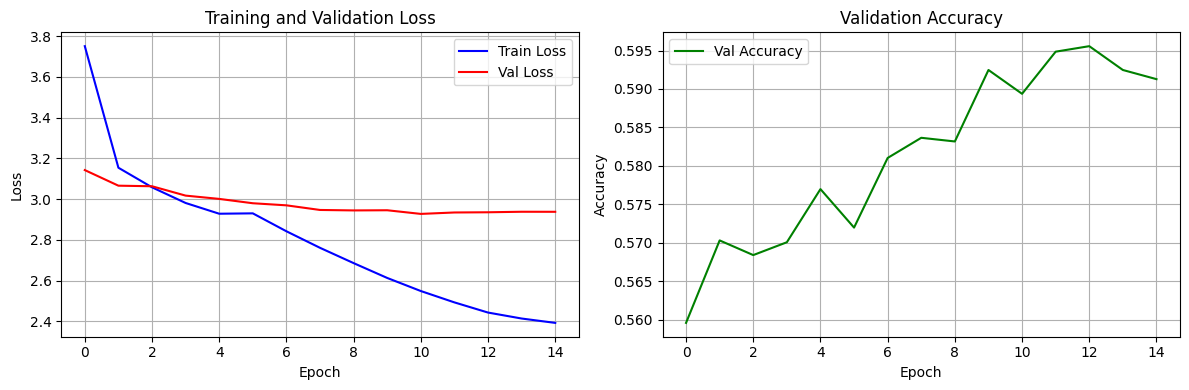


 Best Accuracy: 59.56%
   Final Accuracy: 59.13%


In [22]:
class TrainerWithAttention:
    def __init__(self, model, train_loader, val_loader, vocab, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.vocab = vocab
        self.device = device

        # Hàm loss (KHÔNG dùng class_weights)
        self.criterion = nn.CrossEntropyLoss(
            ignore_index=0,
            label_smoothing=0.1
        )

        # Optimizer & Scheduler
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=5, T_mult=2, eta_min=1e-6
        )
        self.grad_clip = 1.0

        # History
        self.train_losses = []
        self.val_losses = []
        self.val_accuracies = []
        self.best_val_acc = 0.0  # Biến lưu kỷ lục

    def train_epoch(self):
        self.model.train()
        total_loss = 0

        pbar = tqdm(self.train_loader, desc='Training')
        for batch in pbar:
            img_feat = batch['image_features'].to(self.device)
            ques = batch['question'].to(self.device)
            ans = batch['answer'].to(self.device)

            outputs = self.model(img_feat, ques, ans)
            outputs_flat = outputs.reshape(-1, outputs.size(-1))
            targets_flat = ans[:, 1:].reshape(-1)

            loss = self.criterion(outputs_flat, targets_flat)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        return total_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        predictions_list = []
        targets_list = []

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='Validating'):
                img_feat = batch['image_features'].to(self.device)
                ques = batch['question'].to(self.device)
                ans = batch['answer'].to(self.device)


                outputs_tf = self.model(img_feat, ques, ans)
                outputs_flat = outputs_tf.reshape(-1, outputs_tf.size(-1))
                targets_flat = ans[:, 1:].reshape(-1)
                loss = self.criterion(outputs_flat, targets_flat)
                total_loss += loss.item()


                predictions = self.model(img_feat, ques)

                targets = ans[:, 1:]
                pred_len = predictions.size(1)
                tgt_len  = targets.size(1)
                if pred_len < tgt_len:
                    pad = torch.zeros(predictions.size(0), tgt_len - pred_len,
                                      dtype=torch.long).to(self.device)
                    predictions = torch.cat([predictions, pad], dim=1)
                elif pred_len > tgt_len:
                    predictions = predictions[:, :tgt_len]

                mask = targets != 0
                correct += ((predictions == targets) * mask).sum().item()
                total   += mask.sum().item()

                if len(predictions_list) < 20:
                    for i in range(min(2, len(predictions))):
                        pred_text   = self.vocab.decode_answer(predictions[i].cpu().numpy())
                        target_text = batch['answer_text'][i]
                        predictions_list.append(pred_text)
                        targets_list.append(target_text)

        accuracy = correct / total if total > 0 else 0

        print(f"\n Mẫu dự đoán (validation):")
        for i in range(min(5, len(predictions_list))):
            print(f"   Target: {targets_list[i][:30]:<30} | Predict: {predictions_list[i][:30]}")

        return total_loss / len(self.val_loader), accuracy

    def train(self, epochs=15):
        print(" BẮT ĐẦU TRAINING MODEL WITH ATTENTION")
        print("="*60)
        patience = 4
        patience_counter = 0
        for epoch in range(epochs):
            print(f"\n Epoch {epoch+1}/{epochs}")
            print("-" * 40)

            train_loss = self.train_epoch()
            val_loss, val_acc = self.validate()
            self.scheduler.step(epoch + 1)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)

            print(f"\n KẾT QUẢ EPOCH {epoch+1}:")
            print(f"   Train Loss: {train_loss:.4f}")
            print(f"   Val Loss: {val_loss:.4f}")
            print(f"   Val Accuracy: {val_acc:.4f}")

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                torch.save(self.model.state_dict(), 'checkpoints/best_attn_model.pth')
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered")
                break
        print("\n" + "="*60)
        print(" TRAINING COMPLETED!")
        self.plot_results()

    def plot_results(self):
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(self.train_losses, 'b-', label='Train Loss')
        axes[0].plot(self.val_losses, 'r-', label='Val Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(self.val_accuracies, 'g-', label='Val Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        print(f"\n Best Accuracy: {max(self.val_accuracies):.2%}")
        print(f"   Final Accuracy: {self.val_accuracies[-1]:.2%}")

# ==========================================
# KHỞI TẠO VÀ CHẠY TRAIN
# ==========================================
model_with_attention = VQAModelWithAttention(
    vocab_size=len(vocab.question_word2idx),
    answer_size=len(vocab.answer_word2idx),
    feature_dim=2048,
    embed_size=300,
    hidden_size=512,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=pretrained_embeddings
).to(device)

print(" Model Có Attention đã khởi tạo!")
print(f" Số parameters: {sum(p.numel() for p in model_with_attention.parameters()):,}")

trainer_attention = TrainerWithAttention(
    model=model_with_attention,
    train_loader=train_loader,
    val_loader=val_loader,
    vocab=vocab,
    device=device
)

trainer_attention.train(epochs=15)

In [ ]:
print("Đang load mô hình Attention tốt nhất (best_attn_model.pth) để đánh giá...")
model_with_attention.load_state_dict(torch.load('checkpoints/best_attn_model.pth', map_location=device))

# Đánh giá với FullEvaluator
evaluator_attn = FullEvaluator(model_with_attention, vocab, device)
results_attn = evaluator_attn.evaluate(val_loader, num_samples=20)
evaluator_attn.print_results(results_attn)

Đang load mô hình Attention tốt nhất (best_attn_model.pth) để đánh giá...


Evaluating: 100%|██████████| 125/125 [01:03<00:00,  1.98it/s]


 ĐÁNH GIÁ TOÀN DIỆN
Token-level Accuracy: 59.56%
Sentence-level Exact Match: 31.30%
BLEU-4 Score: 0.3140
ROUGE-1: 0.3271
ROUGE-2: 0.0027
ROUGE-L: 0.3269

 MẪU DỰ ĐOÁN

1. Q: Where is he looking?
   Target: down
   Predict: park
    BLEU-4: 0.0000

2. Q: What are the people in the background doing?
   Target: watching
   Predict: skateboard
    BLEU-4: 0.0000

3. Q: What is he on top of?
   Target: picnic table
   Predict: skateboard
    BLEU-4: 0.0000

4. Q: What website copyrighted the picture?
   Target: <unk>
   Predict: broccoli
    BLEU-4: 0.0000

5. Q: Is this a creamy soup?
   Target: no
   Predict: yes
    BLEU-4: 0.0000

6. Q: Is this rice noodle soup?
   Target: yes
   Predict: yes
    ĐÚNG

7. Q: What is to the right of the soup?
   Target: chopsticks
   Predict: broccoli
    BLEU-4: 0.0000

8. Q: What is the man doing in the street?
   Target: walking
   Predict: bike
    BLEU-4: 0.0000

9. Q: How many photo's can you see?
   Target: 1
   Predict: 2
    BLEU-4: 0.0000

10.

## So sánh các chỉ số

Đang đánh giá model Không Attention...


Evaluating: 100%|██████████| 125/125 [01:02<00:00,  1.99it/s]


Đang đánh giá model Có Attention...


Evaluating: 100%|██████████| 125/125 [01:03<00:00,  1.98it/s]



Metric                  Không Attention    Có Attention
-------------------------------------------------------
Token Accuracy                   58.32%          59.56%
Exact Match                      29.00%          31.30%
BLEU-4                           29.25%          31.40%
ROUGE-L                          30.14%          32.69%


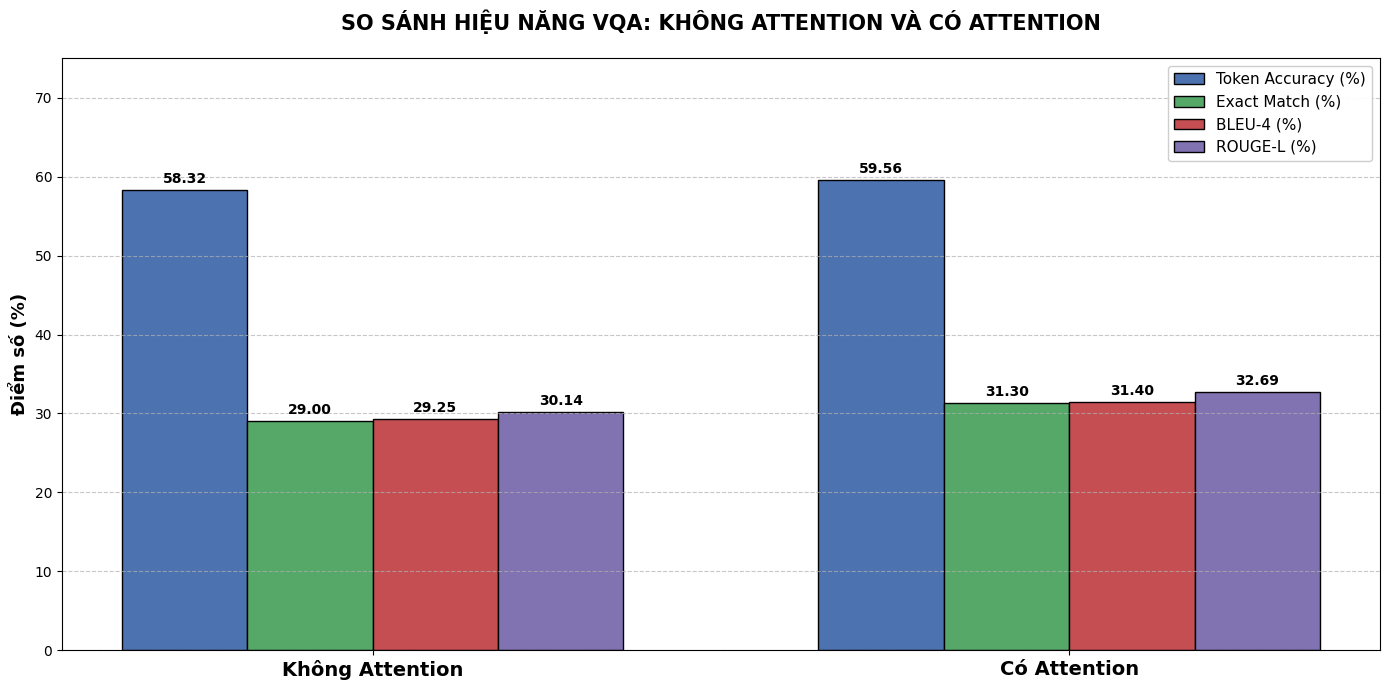

In [24]:
import matplotlib.pyplot as plt
import numpy as np

print("Đang đánh giá model Không Attention...")
evaluator_noattn = FullEvaluator(model_noattn, vocab, device)
results_noattn = evaluator_noattn.evaluate(val_loader)

print("Đang đánh giá model Có Attention...")
evaluator_attn = FullEvaluator(model_with_attention, vocab, device)
results_attn = evaluator_attn.evaluate(val_loader)

models = ['Không Attention', 'Có Attention']

accuracy    = [results_noattn['token_accuracy'] * 100,  results_attn['token_accuracy'] * 100]
exact_match = [results_noattn['exact_match'] * 100,     results_attn['exact_match'] * 100]
bleu_4      = [results_noattn['bleu'] * 100,            results_attn['bleu'] * 100]
rouge_l     = [results_noattn['rougeL'] * 100,          results_attn['rougeL'] * 100]

# In ra để kiểm tra
print(f"\n{'Metric':<20} {'Không Attention':>18} {'Có Attention':>15}")
print("-" * 55)
print(f"{'Token Accuracy':<20} {accuracy[0]:>17.2f}% {accuracy[1]:>14.2f}%")
print(f"{'Exact Match':<20} {exact_match[0]:>17.2f}% {exact_match[1]:>14.2f}%")
print(f"{'BLEU-4':<20} {bleu_4[0]:>17.2f}% {bleu_4[1]:>14.2f}%")
print(f"{'ROUGE-L':<20} {rouge_l[0]:>17.2f}% {rouge_l[1]:>14.2f}%")

# Vẽ biểu đồ
x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - width*1.5, accuracy,    width, label='Token Accuracy (%)', color='#4C72B0', edgecolor='black')
rects2 = ax.bar(x - width*0.5, exact_match, width, label='Exact Match (%)',    color='#55A868', edgecolor='black')
rects3 = ax.bar(x + width*0.5, bleu_4,      width, label='BLEU-4 (%)',         color='#C44E52', edgecolor='black')
rects4 = ax.bar(x + width*1.5, rouge_l,     width, label='ROUGE-L (%)',        color='#8172B2', edgecolor='black')

ax.set_ylabel('Điểm số (%)', fontsize=13, fontweight='bold')
ax.set_title('SO SÁNH HIỆU NĂNG VQA: KHÔNG ATTENTION VÀ CÓ ATTENTION',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, max(max(accuracy), 70) + 5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

fig.tight_layout()
plt.show()

## Heatmap

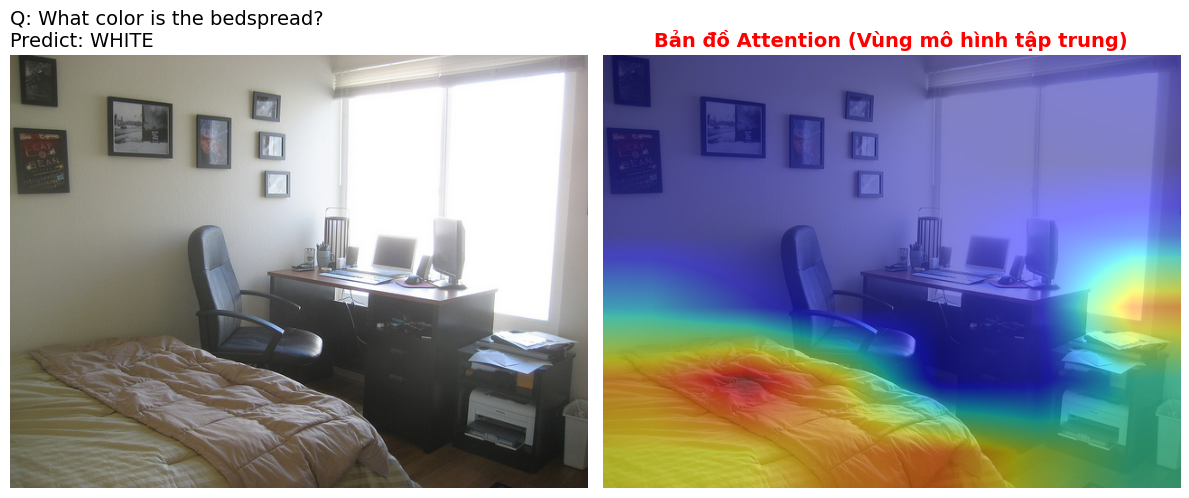

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import cv2

def visualize_attention(image_path, question, model, vocab, extractor, device):
    """
    Hàm hiển thị bức ảnh gốc kèm theo bản đồ nhiệt (heatmap) thể hiện
    sự chú ý (attention) của mô hình vào từng vùng trên ảnh.
    """
    model.eval()

    
    img = Image.open(image_path).convert('RGB')
    img_arr = np.array(img)

    img_tensor = extractor.transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = extractor.feature_extractor(img_tensor)
        features = features.squeeze(0).permute(1, 2, 0)
        pooled = []
        for i in range(0, 14, 2):
            for j in range(0, 14, 2):
                region = features[i:i+2, j:j+2].mean(dim=(0,1))
                pooled.append(region)
        image_features = torch.stack(pooled[:36]).unsqueeze(0) # [1, 36, 2048]

    q_encoded = vocab.encode_question(question, max_len=14)
    q_tensor = torch.LongTensor(q_encoded).unsqueeze(0).to(device)

    with torch.no_grad():
        # Encode câu hỏi
        q_embed = model.embedding(q_tensor)
        _, (hidden, _) = model.question_lstm(q_embed)
        q_combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        v_ques = model.question_proj(q_combined)

        # LẤY TRỌNG SỐ ATTENTION TỪ MODULE SPATIAL ATTENTION
        _, attn_weights = model.attention(image_features, v_ques) # [1, 36, 1]

        # Chạy nốt phần Decoder để lấy text dự đoán
        predictions = model(image_features, q_tensor)
        pred_text = vocab.decode_answer(predictions[0].cpu().numpy())

    #  Xử lý Attention Weights thành Heatmap (Lưới 6x6)
    attn_weights = attn_weights.squeeze().cpu().numpy() # Mảng 36 phần tử
    attn_grid = attn_weights.reshape(6, 6) # Đưa về lưới 6x6

    # Resize heatmap cho bằng kích thước ảnh gốc
    heatmap = cv2.resize(attn_grid, (img_arr.shape[1], img_arr.shape[0]))
    # Chuẩn hóa về [0, 1]
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(img_arr)
    ax1.axis('off')
    ax1.set_title(f"Q: {question}\nPredict: {pred_text.upper()}", fontsize=14, loc='left')

    ax2.imshow(img_arr)
    ax2.imshow(heatmap, cmap='jet', alpha=0.5)
    ax2.axis('off')
    ax2.set_title("Bản đồ Attention (Vùng mô hình tập trung)", fontsize=14, color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

sample_idx = 20
sample = val_dataset[sample_idx]
img_id = sample['image_id']
img_path = os.path.join('data/images/val2014', f"COCO_val2014_{img_id:012d}.jpg")
question = sample['question_text']

visualize_attention(img_path, question, model_with_attention, vocab, extractor, device)

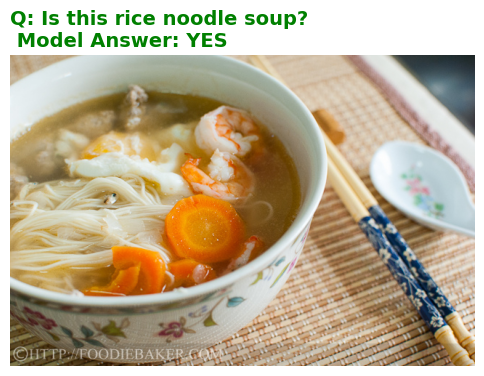

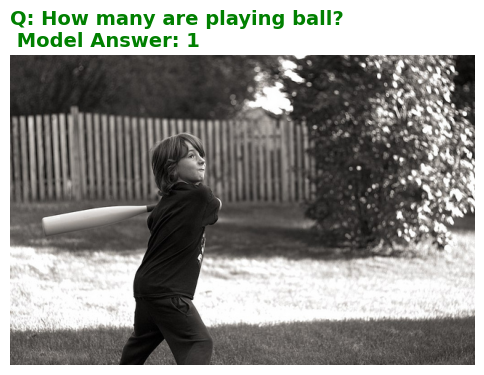

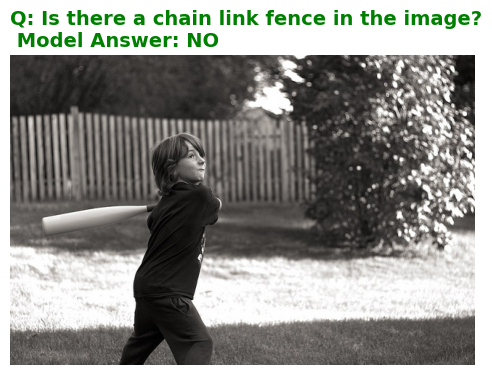

In [47]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_good_predictions(val_loader, model, vocab, device, num_to_show=3):
    model.eval()
    found = 0

    with torch.no_grad():
        for batch in val_loader:
            img_feat = batch['image_features'].to(device)
            ques = batch['question'].to(device)

            # Dự đoán
            predictions = model(img_feat, ques)

            # Kiểm tra xem câu nào đúng
            for i in range(len(ques)):
                target_text = batch['answer_text'][i]
                pred_text = vocab.decode_answer(predictions[i].cpu().numpy())


                if pred_text == target_text and target_text != '<unk>':
                    img_id = batch['image_id'][i].item()
                    img_path = os.path.join('data/images/val2014', f"COCO_val2014_{img_id:012d}.jpg")

                    try:
                        img = Image.open(img_path).convert('RGB')
                        plt.figure(figsize=(6, 6))
                        plt.imshow(img)
                        plt.axis('off')

                        question_text = batch['question_text'][i]

                        # Hiển thị text lên biểu đồ
                        plt.title(f"Q: {question_text}\n Model Answer: {pred_text.upper()}",
                                  color='green', fontsize=14, fontweight='bold', loc='left')
                        plt.show()

                        found += 1
                        if found >= num_to_show:
                            return
                    except Exception as e:
                        continue

show_good_predictions(val_loader, model_with_attention, vocab, device, num_to_show=3)

## Phân tích lỗi theo câu hỏi

 Đang inference No Attention...


Inferencing: 100%|██████████| 125/125 [01:03<00:00,  1.97it/s]


 Đang inference With Attention...


Inferencing: 100%|██████████| 125/125 [01:04<00:00,  1.94it/s]



  PHÂN TÍCH THEO LOẠI CÂU HỎI: NO ATTENTION vs WITH ATTENTION
  Loại          No Attn Acc     Attn Acc   Chênh lệch    Số mẫu
────────────────────────────────────────────────────────────────────────
  Yes/No             48.14%        48.98%  +     +0.84%      833
  Counting           27.15%        28.05%  +     +0.90%      221
  Open               11.52%        15.64%  +     +4.12%      946
  ALL                28.50%        30.90%  +     +2.40%     2000


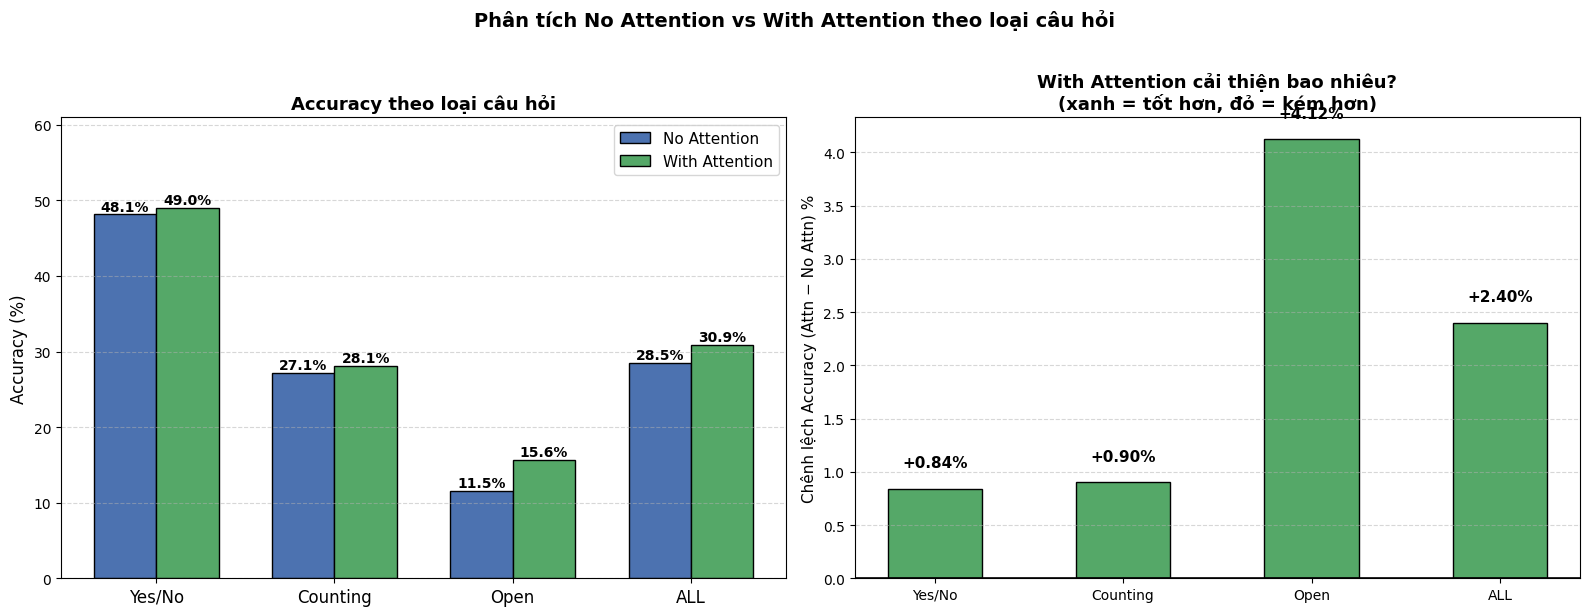


  MẪU LỖI ĐIỂN HÌNH TỪNG LOẠI CÂU HỎI

  [Yes/No] — 339 mẫu cả 2 model sai, hiển thị 3:
  ────────────────────────────────────────────────────────────────────
    Q      : Is this a creamy soup?
    Target : no
    No Attn: yes
    Attn   : yes

    Q      : Is it daylight in this picture?
    Target : yes
    No Attn: no
    Attn   : no

    Q      : Did the batter hit the ball?
    Target : yes
    No Attn: no
    Attn   : no


  [Counting] — 150 mẫu cả 2 model sai, hiển thị 3:
  ────────────────────────────────────────────────────────────────────
    Q      : How many pictures are there?
    Target : 7
    No Attn: 1
    Attn   : 1

    Q      : How many frames are on the wall?
    Target : 7
    No Attn: 1
    Attn   : 1

    Q      : How many pictures on the wall?
    Target : 7
    No Attn: 1
    Attn   : 1


  [Open] — 776 mẫu cả 2 model sai, hiển thị 3:
  ────────────────────────────────────────────────────────────────────
    Q      : Where is he looking?
    Target : down
  

In [ ]:


from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

def classify_question(q):
    q = q.lower().strip()
    if q.startswith(('is ', 'are ', 'does ', 'do ', 'was ', 'were ',
                      'can ', 'has ', 'have ', 'did ', 'could ', 'would ')):
        return 'Yes/No'
    elif q.startswith('how many') or q.startswith('how much'):
        return 'Counting'
    else:
        return 'Open'


def run_inference(model, val_loader, vocab, device):
    model.eval()
    results = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Inferencing'):
            img_feat = batch['image_features'].to(device)
            ques     = batch['question'].to(device)
            preds    = model(img_feat, ques)   

            for i in range(len(ques)):
                pred_text   = vocab.decode_answer(preds[i].cpu().numpy())
                target_text = batch['answer_text'][i]
                q_text      = batch['question_text'][i]
                q_type      = classify_question(q_text)

                results.append({
                    'question':  q_text,
                    'type':      q_type,
                    'target':    target_text,
                    'predicted': pred_text,
                    'correct':   pred_text == target_text
                })

    return results


#Tính metrics theo từng loại 
def compute_metrics_by_type(results):
    stats = defaultdict(lambda: {'correct': 0, 'total': 0})

    for r in results:
        t = r['type']
        stats[t]['total']   += 1
        stats[t]['correct'] += int(r['correct'])

    stats['ALL']['total']   = len(results)
    stats['ALL']['correct'] = sum(r['correct'] for r in results)

    metrics = {}
    for q_type, s in stats.items():
        metrics[q_type] = {
            'accuracy': s['correct'] / s['total'] if s['total'] > 0 else 0,
            'correct':  s['correct'],
            'total':    s['total']
        }
    return metrics


def print_comparison_table(metrics_no, metrics_attn):
    q_types = ['Yes/No', 'Counting', 'Open', 'ALL']

    print('\n' + '=' * 72)
    print('  PHÂN TÍCH THEO LOẠI CÂU HỎI: NO ATTENTION vs WITH ATTENTION')
    print('=' * 72)
    print(f"  {'Loại':<12} {'No Attn Acc':>12} {'Attn Acc':>12} {'Chênh lệch':>12}  {'Số mẫu':>8}")
    print('─' * 72)

    for t in q_types:
        no_acc   = metrics_no[t]['accuracy']   * 100
        att_acc  = metrics_attn[t]['accuracy'] * 100
        diff     = att_acc - no_acc
        total    = metrics_no[t]['total']
        sign     = '+' if diff >= 0 else ''
        winner   = '' if diff > 0 else ('' if diff < 0 else '')
        print(f"  {t:<12} {no_acc:>11.2f}%  {att_acc:>11.2f}%  "
              f"{sign}{diff:>+10.2f}%  {winner}  {total:>5}")

    print('=' * 72)


def plot_comparison(metrics_no, metrics_attn):
    q_types  = ['Yes/No', 'Counting', 'Open', 'ALL']
    no_accs  = [metrics_no[t]['accuracy']   * 100 for t in q_types]
    att_accs = [metrics_attn[t]['accuracy'] * 100 for t in q_types]

    x     = np.arange(len(q_types))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ 1: grouped bar chart
    bars1 = axes[0].bar(x - width/2, no_accs,  width, label='No Attention',
                        color='#4C72B0', edgecolor='black')
    bars2 = axes[0].bar(x + width/2, att_accs, width, label='With Attention',
                        color='#55A868', edgecolor='black')

    for bar in bars1:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
    for bar in bars2:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(q_types, fontsize=12)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_title('Accuracy theo loại câu hỏi', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].set_ylim(0, max(max(no_accs), max(att_accs)) + 12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Biểu đồ 2: chênh lệch (Attention - NoAttention)
    diffs  = [a - n for a, n in zip(att_accs, no_accs)]
    colors = ['#55A868' if d >= 0 else '#C44E52' for d in diffs]
    bars3  = axes[1].bar(q_types, diffs, color=colors, edgecolor='black', width=0.5)

    for bar, d in zip(bars3, diffs):
        ypos = bar.get_height() + 0.2 if d >= 0 else bar.get_height() - 0.8
        axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                     f'{d:+.2f}%', ha='center', fontsize=11, fontweight='bold')

    axes[1].axhline(0, color='black', linewidth=1.2)
    axes[1].set_ylabel('Chênh lệch Accuracy (Attn − No Attn) %', fontsize=11)
    axes[1].set_title('With Attention cải thiện bao nhiêu?\n(xanh = tốt hơn, đỏ = kém hơn)',
                      fontsize=13, fontweight='bold')
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle('Phân tích No Attention vs With Attention theo loại câu hỏi',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def print_error_samples(results_no, results_attn, n_each=3):
    q_types = ['Yes/No', 'Counting', 'Open']

    print('\n' + '=' * 72)
    print('  MẪU LỖI ĐIỂN HÌNH TỪNG LOẠI CÂU HỎI')
    print('=' * 72)

    paired = list(zip(results_no, results_attn))

    for q_type in q_types:
        both_wrong = [(r_no, r_att) for r_no, r_att in paired
                      if r_no['type'] == q_type
                      and not r_no['correct']
                      and not r_att['correct']]

        print(f"\n  [{q_type}] — {len(both_wrong)} mẫu cả 2 model sai, hiển thị {n_each}:")
        print('  ' + '─' * 68)

        for r_no, r_att in both_wrong[:n_each]:
            print(f"    Q      : {r_no['question']}")
            print(f"    Target : {r_no['target']}")
            print(f"    No Attn: {r_no['predicted']}")
            print(f"    Attn   : {r_att['predicted']}")
            print()


print(' Đang inference No Attention...')
results_no = run_inference(model_noattn, val_loader, vocab, device)

print(' Đang inference With Attention...')
results_attn = run_inference(model_with_attention, val_loader, vocab, device)

metrics_no   = compute_metrics_by_type(results_no)
metrics_attn = compute_metrics_by_type(results_attn)

print_comparison_table(metrics_no, metrics_attn)
plot_comparison(metrics_no, metrics_attn)
print_error_samples(results_no, results_attn, n_each=3)


## Phân tích OVERFITTING / UNDERFITTING

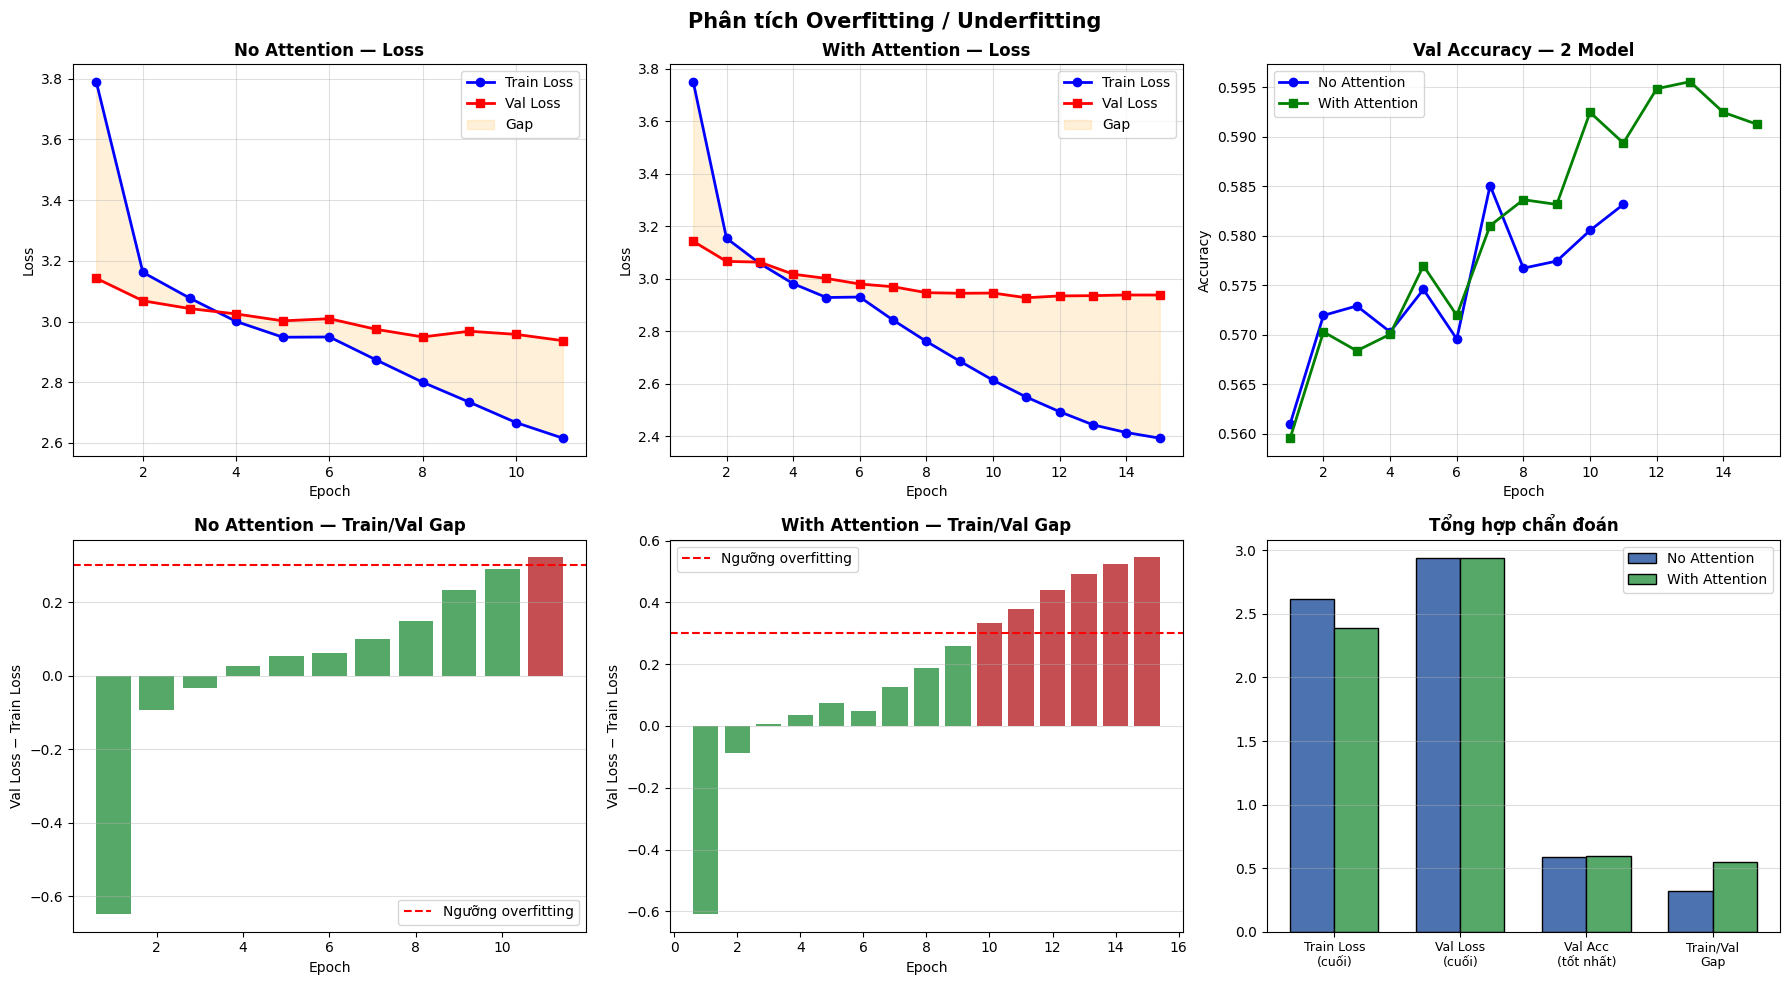


  CHẨN ĐOÁN FITTING

  [No Attention]
    Train Loss cuối  : 2.6157
    Val Loss cuối    : 2.9371
    Gap cuối         : 0.3213
    Gap trung bình   : 0.0417
    Best Val Acc     : 58.51%
    Chẩn đoán        :   UNDERFITTING — model chưa học đủ

  [With Attention]
    Train Loss cuối  : 2.3919
    Val Loss cuối    : 2.9373
    Gap cuối         : 0.5455
    Gap trung bình   : 0.1836
    Best Val Acc     : 59.56%
    Chẩn đoán        :   OVERFITTING — val loss tăng, train loss giảm


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

def analyze_fitting(trainer_no, trainer_attn):

    epochs_no   = list(range(1, len(trainer_no.train_losses) + 1))
    epochs_attn = list(range(1, len(trainer_attn.train_losses) + 1))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Phân tích Overfitting / Underfitting', fontsize=15, fontweight='bold')

    # Biểu đồ 1: Loss NoAttention 
    axes[0][0].plot(epochs_no, trainer_no.train_losses, 'b-o', label='Train Loss', linewidth=2)
    axes[0][0].plot(epochs_no, trainer_no.val_losses,   'r-s', label='Val Loss',   linewidth=2)
    axes[0][0].fill_between(epochs_no,
                             trainer_no.train_losses,
                             trainer_no.val_losses,
                             alpha=0.15, color='orange', label='Gap')
    axes[0][0].set_title('No Attention — Loss', fontweight='bold')
    axes[0][0].set_xlabel('Epoch')
    axes[0][0].set_ylabel('Loss')
    axes[0][0].legend()
    axes[0][0].grid(True, alpha=0.4)

    # Biểu đồ 2: Loss WithAttention 
    axes[0][1].plot(epochs_attn, trainer_attn.train_losses, 'b-o', label='Train Loss', linewidth=2)
    axes[0][1].plot(epochs_attn, trainer_attn.val_losses,   'r-s', label='Val Loss',   linewidth=2)
    axes[0][1].fill_between(epochs_attn,
                             trainer_attn.train_losses,
                             trainer_attn.val_losses,
                             alpha=0.15, color='orange', label='Gap')
    axes[0][1].set_title('With Attention — Loss', fontweight='bold')
    axes[0][1].set_xlabel('Epoch')
    axes[0][1].set_ylabel('Loss')
    axes[0][1].legend()
    axes[0][1].grid(True, alpha=0.4)

    # Biểu đồ 3: Val Accuracy cả 2 
    axes[0][2].plot(epochs_no,   trainer_no.val_accuracies,   'b-o', label='No Attention',   linewidth=2)
    axes[0][2].plot(epochs_attn, trainer_attn.val_accuracies, 'g-s', label='With Attention', linewidth=2)
    axes[0][2].set_title('Val Accuracy — 2 Model', fontweight='bold')
    axes[0][2].set_xlabel('Epoch')
    axes[0][2].set_ylabel('Accuracy')
    axes[0][2].legend()
    axes[0][2].grid(True, alpha=0.4)

    #  Biểu đồ 4: Train/Val gap theo epoch (NoAttention)
    gap_no = [v - t for t, v in zip(trainer_no.train_losses, trainer_no.val_losses)]
    axes[1][0].bar(epochs_no, gap_no, color=['#C44E52' if g > 0.3 else '#55A868' for g in gap_no])
    axes[1][0].axhline(0.3, color='red', linestyle='--', label='Ngưỡng overfitting')
    axes[1][0].set_title('No Attention — Train/Val Gap', fontweight='bold')
    axes[1][0].set_xlabel('Epoch')
    axes[1][0].set_ylabel('Val Loss − Train Loss')
    axes[1][0].legend()
    axes[1][0].grid(axis='y', alpha=0.4)

    #  Biểu đồ 5: Train/Val gap theo epoch (WithAttention) 
    gap_attn = [v - t for t, v in zip(trainer_attn.train_losses, trainer_attn.val_losses)]
    axes[1][1].bar(epochs_attn, gap_attn, color=['#C44E52' if g > 0.3 else '#55A868' for g in gap_attn])
    axes[1][1].axhline(0.3, color='red', linestyle='--', label='Ngưỡng overfitting')
    axes[1][1].set_title('With Attention — Train/Val Gap', fontweight='bold')
    axes[1][1].set_xlabel('Epoch')
    axes[1][1].set_ylabel('Val Loss − Train Loss')
    axes[1][1].legend()
    axes[1][1].grid(axis='y', alpha=0.4)

    #  Biểu đồ 6: Chẩn đoán tổng hợp 
    categories = ['Train Loss\n(cuối)', 'Val Loss\n(cuối)', 'Val Acc\n(tốt nhất)', 'Train/Val\nGap']
    no_vals    = [trainer_no.train_losses[-1],
                  trainer_no.val_losses[-1],
                  max(trainer_no.val_accuracies),
                  gap_no[-1]]
    attn_vals  = [trainer_attn.train_losses[-1],
                  trainer_attn.val_losses[-1],
                  max(trainer_attn.val_accuracies),
                  gap_attn[-1]]

    x     = np.arange(len(categories))
    width = 0.35
    axes[1][2].bar(x - width/2, no_vals,   width, label='No Attention',   color='#4C72B0', edgecolor='black')
    axes[1][2].bar(x + width/2, attn_vals, width, label='With Attention', color='#55A868', edgecolor='black')
    axes[1][2].set_title('Tổng hợp chẩn đoán', fontweight='bold')
    axes[1][2].set_xticks(x)
    axes[1][2].set_xticklabels(categories, fontsize=9)
    axes[1][2].legend()
    axes[1][2].grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()

    print('\n' + '=' * 65)
    print('  CHẨN ĐOÁN FITTING')
    print('=' * 65)

    for name, trainer, gap in [('No Attention',   trainer_no,   gap_no),
                                 ('With Attention', trainer_attn, gap_attn)]:
        avg_gap    = np.mean(gap)
        final_gap  = gap[-1]
        train_loss = trainer.train_losses[-1]
        val_loss   = trainer.val_losses[-1]
        best_acc   = max(trainer.val_accuracies)

        print(f'\n  [{name}]')
        print(f'    Train Loss cuối  : {train_loss:.4f}')
        print(f'    Val Loss cuối    : {val_loss:.4f}')
        print(f'    Gap cuối         : {final_gap:.4f}')
        print(f'    Gap trung bình   : {avg_gap:.4f}')
        print(f'    Best Val Acc     : {best_acc:.2%}')

        if train_loss > 2.5 and best_acc < 0.65:
            diagnosis = '  UNDERFITTING — model chưa học đủ'
        elif final_gap > 0.5:
            diagnosis = '  OVERFITTING — val loss tăng, train loss giảm'
        elif final_gap > 0.3:
            diagnosis = ' CHỚM OVERFITTING — gap đang tăng dần'
        else:
            diagnosis = ' BÌNH THƯỜNG — train/val cân bằng'

        print(f'    Chẩn đoán        : {diagnosis}')



analyze_fitting(trainer_noattn, trainer_attention)
